In [1]:
# Set up

In [2]:
# Setup jdk4py Java
import jdk4py
import os
os.environ["JAVA_HOME"] = str(jdk4py.JAVA_HOME)
expected = str(jdk4py.JAVA_HOME)
actual = os.getenv("JAVA_HOME")

assert actual == expected, f"\033[31mJAVA_HOME mismatch: {actual!r} != {expected!r}\033[0m"
print(f"JAVA_HOME set correctly")

# Start JVM
import os
import jpype
import jpype.imports
import orekit_jpype as orekit

if not jpype.isJVMStarted():
    orekit.initVM()

print("JVM started:", jpype.isJVMStarted())

# Import orekit data and setup
from orekit_jpype.pyhelpers import setup_orekit_curdir
setup_orekit_curdir("../data")


JAVA_HOME set correctly


JVM started: True


In [3]:
from org.orekit.utils import Constants
from org.hipparchus.geometry.euclidean.threed import Vector3D
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.frames import FramesFactory
from org.orekit.utils import PVCoordinates
from org.orekit.orbits import KeplerianOrbit, PositionAngleType

# initial time
# this variable is only used for calculating propagation time start+t
initialDate = AbsoluteDate(
    2005,   # year
    4,      # month
    2,      # day
    21,     # hour
    37,     # minute
    0.0,    # second
    TimeScalesFactory.getUTC()
)

# cartesian starting state
# TODO perhaps change to keplerian from the start?
position = Vector3D(-6142438.668, 3492467.560, -25767.25680)
velocity = Vector3D(505.8479685, 942.7809215, 7435.922231)

pv = PVCoordinates(position, velocity)

# orbit construction
initialOrbit = KeplerianOrbit(
    pv,
    FramesFactory.getEME2000(),
    initialDate,
    Constants.EIGEN5C_EARTH_MU
)

print(initialOrbit)

Keplerian parameters: {a: 7069220.386682823; e: 4.777356060557311E-4; i: 98.18525099174988; pa: 13.741061002484528; raan: 150.34825333049; v: -13.952151446378437;}


In [4]:
# BULLSH*T PROPAGATION VIBE CODED I'M NOT SURE WHAT IS GOING ON HERE
# TODO rewrite and annotate

from org.orekit.propagation.numerical import NumericalPropagator
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState
from org.orekit.orbits import OrbitType
from org.orekit.utils import IERSConventions


minStep = 0.001
maxStep = 1000.0
positionTolerance = 10.0

integrator = DormandPrince853Integrator(
    minStep,
    maxStep,
    positionTolerance,
    positionTolerance
)

propagator = NumericalPropagator(integrator)
propagator.setOrbitType(OrbitType.CARTESIAN)

propagator.setInitialState(SpacecraftState(initialOrbit))

from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.frames import ITRFVersion

provider = GravityFieldFactory.getNormalizedProvider(30, 0)

earthFrame = FramesFactory.getITRF(
    IERSConventions.IERS_2010,
    True
)

# Gravitational Force Model
gravity_force = HolmesFeatherstoneAttractionModel(earthFrame, provider)

propagator.addForceModel(gravity_force)

import matplotlib.pyplot as plt

times = []
raan = []
omega = []
a_list = []
e_list = []
i_list = []
v_list = []

for k in range(500):
    t = k * 60.0  # 1 -minute steps

    state = propagator.propagate(initialDate.shiftedBy(t))
    orbit = state.getOrbit()

    kepler = KeplerianOrbit(orbit)

    times.append(t / 3600)  # a minutes
    a_list.append(kepler.getA())
    raan.append(kepler.getRightAscensionOfAscendingNode())
    omega.append(kepler.getPerigeeArgument())
    e_list.append(kepler.getE())
    i_list.append(kepler.getI())
    v_list.append(kepler.getTrueAnomaly())

print("done")

/home/cihat/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


done


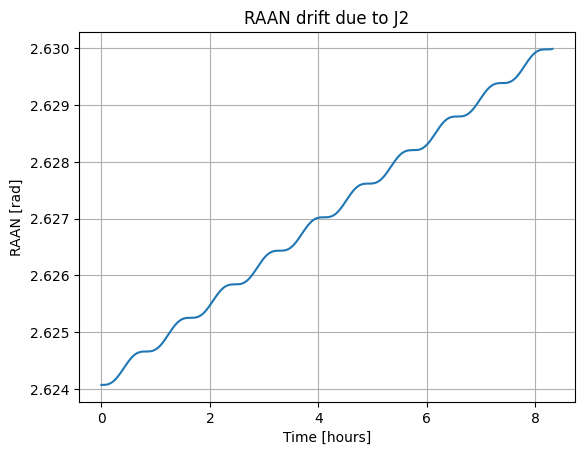

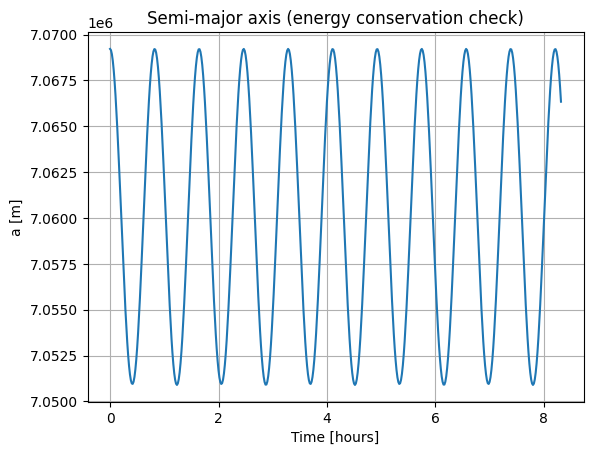

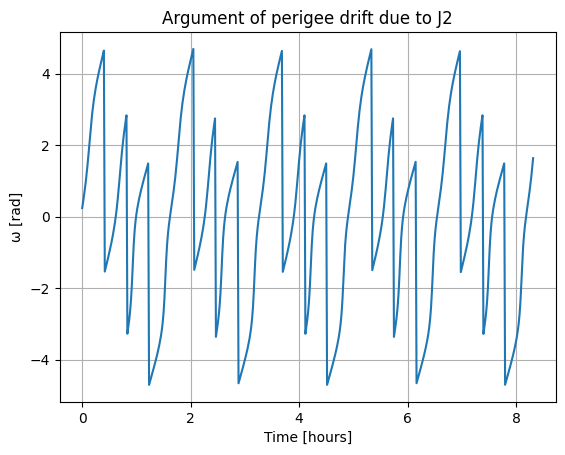

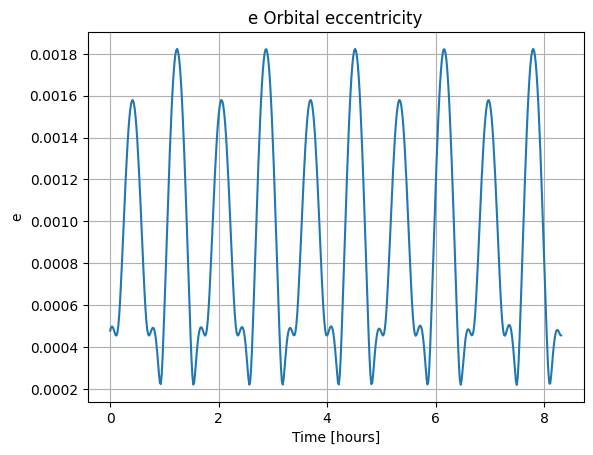

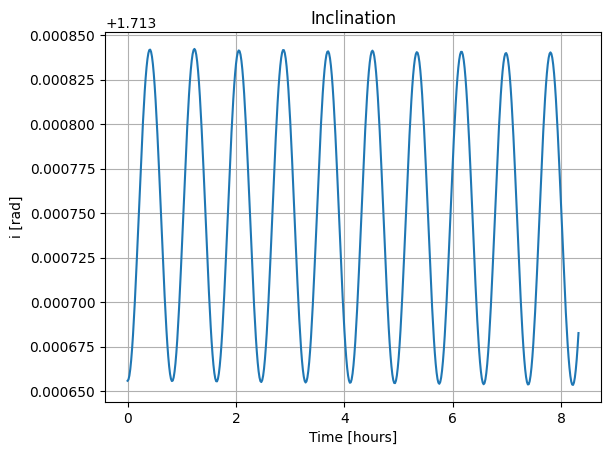

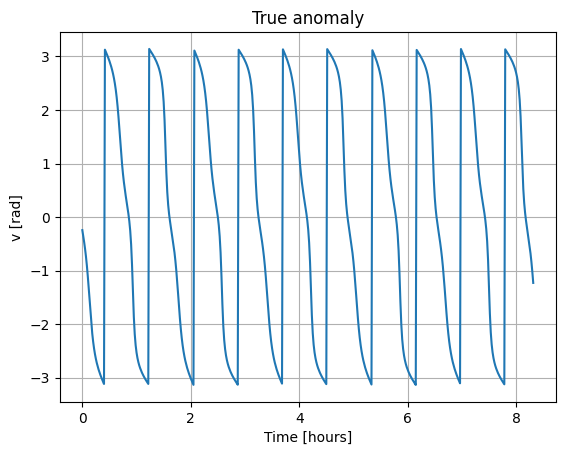

In [8]:
plt.plot(times, raan)
plt.title("RAAN drift due to J2")
plt.xlabel("Time [hours]")
plt.ylabel("RAAN [rad]")
plt.grid()
plt.show()

plt.plot(times, a_list)
plt.title("Semi-major axis (energy conservation check)")
plt.xlabel("Time [hours]")
plt.ylabel("a [m]")
plt.grid()
plt.show()

plt.plot(times, omega)
plt.title("Argument of perigee drift due to J2")
plt.xlabel("Time [hours]")
plt.ylabel("ω [rad]")
plt.grid()
plt.show()

plt.plot(times, e_list)
plt.title("e Orbital eccentricity")
plt.xlabel("Time [hours]")
plt.ylabel("e")
plt.grid()
plt.show()

plt.plot(times, i_list)
plt.title("Inclination")
plt.xlabel("Time [hours]")
plt.ylabel("i [rad]")
plt.grid()
plt.show()

plt.plot(times, v_list)
plt.title("True anomaly")
plt.xlabel("Time [hours]")
plt.ylabel("v [rad]")
plt.grid()
plt.show()

In [6]:

import pandas as pd

df_raw = pd.DataFrame({
    "t_hours": times, "a": a_list, "e": e_list, 
    "i": i_list, "omega": omega, "raan": raan, "v": v_list
})

df_raw.to_csv("raw_orbit_data.csv", index=False)
print("The data saved as 'raw_orbit_data.csv'.")

The data saved as 'raw_orbit_data.csv'.


In [7]:
# 6. HÜCRE
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df_proc = df_raw.copy()

# convert angles sin/cos (i, omega, raan, v)
for col in ['i', 'omega', 'raan', 'v']:
    df_proc[f'sin_{col}'] = np.sin(df_proc[col])
    df_proc[f'cos_{col}'] = np.cos(df_proc[col])
    df_proc = df_proc.drop(columns=[col])

# 'a' ve 'e' değerlerini normalize et (0-1 arası)
scaler = MinMaxScaler()
df_proc[['a', 'e']] = scaler.fit_transform(df_proc[['a', 'e']])

df_proc.to_csv("processed_orbit_data.csv", index=False)
print("Processed data saved as 'processed_orbit_data.csv'")

Processed data saved as 'processed_orbit_data.csv'
